In [1]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model

In [2]:
model_1 = load_model("../models/MobileNetV2_BiLSTM.h5")
model_2 = load_model("../models/MobileNetV2_BiLSTM_best.h5")

In [3]:
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
SEQUENCE_LENGTH = 16
DATASET_DIR = "../data/"
CLASSES_LIST = ["NonViolence", "Violence"]

In [4]:
X_test = np.load(DATASET_DIR + "ProcessedData/X_test.npy")
y_test = np.load(DATASET_DIR + "ProcessedData/y_test.npy")

In [5]:
# Generate raw probability predictions
y_pred_1_proba = model_1.predict(X_test)
y_pred_2_proba = model_2.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 202s 18s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 184s 19s/step


In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [12]:
if y_pred_1_proba.shape[1] == 2:
    y_pred_1 = np.argmax(y_pred_1_proba, axis=1)
    y_pred_2 = np.argmax(y_pred_2_proba, axis=1)
# Or if output is shape (n_samples, 1) => sigmoid
else:
    y_pred_1 = (y_pred_1_proba > 0.5).astype(int).flatten()
    y_pred_2 = (y_pred_2_proba > 0.5).astype(int).flatten()

In [14]:
y_test_labels = np.argmax(y_test, axis=1)

# Confusion Matrix & Classification Report

In [16]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    # Classification report
    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_true, y_pred, target_names=CLASSES_LIST))

    # Basic metrics
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=CLASSES_LIST, yticklabels=CLASSES_LIST)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

### First Model Evaluation


Classification Report for MobileNetV2_BiLSTM
              precision    recall  f1-score   support

 NonViolence       0.98      0.96      0.97        99
    Violence       0.96      0.98      0.97       101

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

Accuracy:  0.9700
Precision: 0.9612
Recall:    0.9802
F1 Score:  0.9706


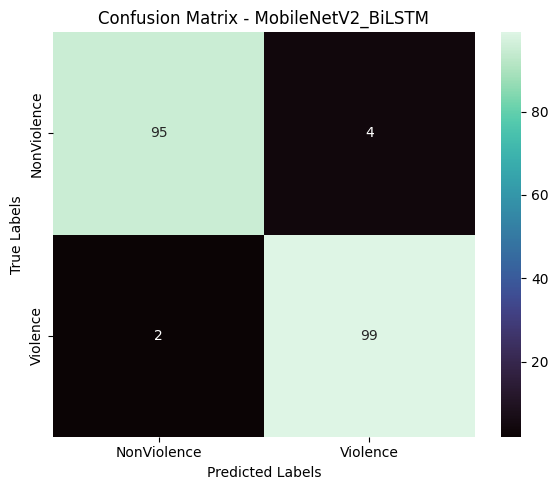

In [ ]:

evaluate_model(y_test_labels, y_pred_1, "MobileNetV2_BiLSTM")

The first model didn't use the lowest val loss, and more on maximizing the accuracy, so there might be some problems

### Best Model Evaluation


Classification Report for MobileNetV2_BiLSTM_best
              precision    recall  f1-score   support

 NonViolence       0.98      0.89      0.93        99
    Violence       0.90      0.98      0.94       101

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200

Accuracy:  0.9350
Precision: 0.9000
Recall:    0.9802
F1 Score:  0.9384


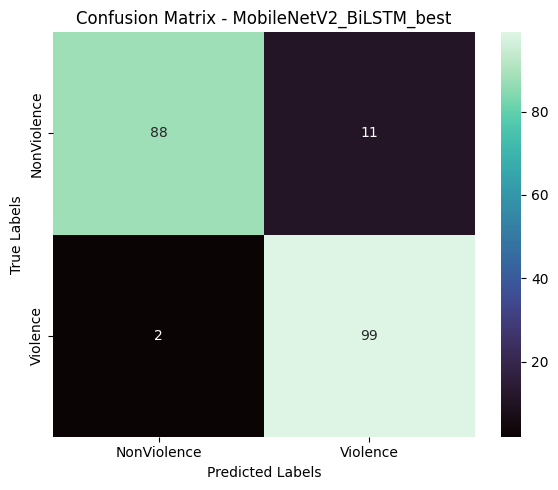

In [18]:
evaluate_model(y_test_labels, y_pred_2, "MobileNetV2_BiLSTM_best")

This model will show better result, even though lower score on the metrics. This happens because this model has the lowest val loss.

# Real World Metrics

In [19]:
import time

In [20]:
def evaluate_real_world_metrics(model, X_sample, model_path, model_name="Model"):
    print(f"\nReal-World Metrics for {model_name}:")

    # Inference Time
    start = time.time()
    model.predict(X_sample)
    end = time.time()
    inference_time = (end - start) / len(X_sample)
    print(f"Inference Time per sample: {inference_time:.6f} seconds")

    # Model Size
    size_bytes = os.path.getsize(model_path)
    size_mb = size_bytes / (1024 * 1024)
    print(f"Model Size: {size_mb:.2f} MB")


### First Model

In [21]:
evaluate_real_world_metrics(model_1, X_test[:100], "../models/MobileNetV2_BiLSTM.h5", "MobileNetV2_BiLSTM")


Real-World Metrics for MobileNetV2_BiLSTM:
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step
Inference Time per sample: 0.498407 seconds
Model Size: 26.44 MB


### Best Model

In [22]:
evaluate_real_world_metrics(model_2, X_test[:100], "../models/MobileNetV2_BiLSTM_best.h5", "MobileNetV2_BiLSTM_best")


Real-World Metrics for MobileNetV2_BiLSTM_best:
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step
Inference Time per sample: 0.298605 seconds
Model Size: 26.44 MB


This model shows a much better inference time/s

# Calibration Curve + ECE

In [23]:
from sklearn.calibration import CalibrationDisplay

In [30]:
def plot_calibration(y_true, y_proba, model_name="Model", n_bins=10):
    # Use only class 1 probability (Violence)
    if y_proba.shape[1] == 2:
        y_proba_class1 = y_proba[:, 1]
    else:
        y_proba_class1 = y_proba.flatten()

    # Reliability Plot (Calibration Curve)
    display = CalibrationDisplay.from_predictions(
        y_true, y_proba_class1, n_bins=n_bins, strategy='uniform'
    )
    display.ax_.set_title(f"Calibration Curve - {model_name}")
    plt.grid(True)
    plt.show()

    # Manual ECE Calculation (Expected Calibration Error)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_proba_class1, bin_edges) - 1
    ece = 0.0
    max_ce = 0.0  # Maximum Calibration Error
    
    for i in range(n_bins):
        bin_mask = bin_ids == i
        if np.any(bin_mask):
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_proba_class1[bin_mask])
            bin_abs_err = abs(bin_acc - bin_conf)
            bin_weight = np.sum(bin_mask) / len(y_true)
            ece += bin_weight * bin_abs_err
            max_ce = max(max_ce, bin_abs_err)
    
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Maximum Calibration Error (MCE): {max_ce:.4f}")

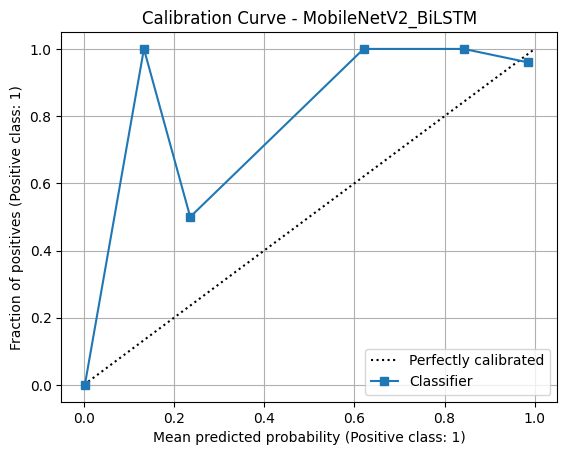

Expected Calibration Error (ECE): 0.0240
Maximum Calibration Error (MCE): 0.8667


In [31]:
plot_calibration(y_test_labels, y_pred_1_proba, "MobileNetV2_BiLSTM")

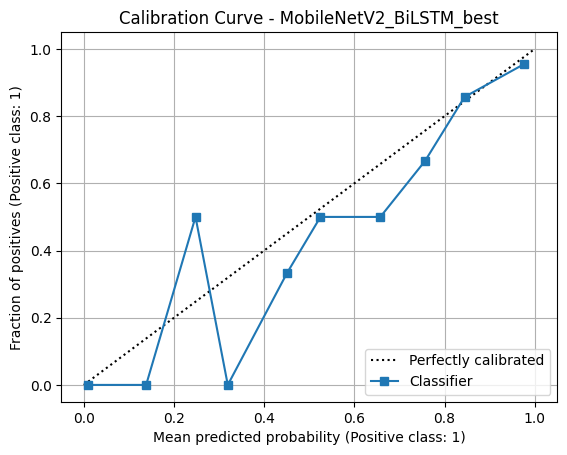

Expected Calibration Error (ECE): 0.0300
Maximum Calibration Error (MCE): 0.3193


In [32]:

plot_calibration(y_test_labels, y_pred_2_proba, "MobileNetV2_BiLSTM_best")